#### Experiment A - Finding relationship between Demographic Attributes and Disease Labels


In [1]:
import pandas as pd
from scipy.stats import chi2_contingency

# Define your CheXpert disease labels (14 labels)
disease_labels = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion',
    'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax',
    'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices'
]

# Demographic columns - one-hot encoded
demographic_groups = {
    "Race": [
    'PRIMARY_RACE_Asian', 'PRIMARY_RACE_Asian - Historical Conv', 'PRIMARY_RACE_Asian, Hispanic',
    'PRIMARY_RACE_Asian, non-Hispanic', 'PRIMARY_RACE_Black or African American', 'PRIMARY_RACE_Black, Hispanic', 'PRIMARY_RACE_Black, non-Hispanic',
    'PRIMARY_RACE_White', 'PRIMARY_RACE_White or Caucasian', 'PRIMARY_RACE_White, Hispanic', 'PRIMARY_RACE_White, non-Hispanic'
    ],
    "Age": [
        'AGE_GROUP_AGE_0_30', 'AGE_GROUP_AGE_31_50',
        'AGE_GROUP_AGE_51_70', 'AGE_GROUP_AGE_71_plus'
    ],
    "Sex": [
        'GENDER_Male', 'GENDER_Female'
    ]
}

# Load your dataframe
df = pd.read_csv("/mnt/Internal/MedImage/chexpert_balanced_for_training_2000_per_label_dis+demog+age.csv")

# Function to run chi-square between disease and each demographic category
def min_pvalue_chi2(disease, demo_cols):
    group_col = df[demo_cols].idxmax(axis=1)  # get group from one-hot
    contingency = pd.crosstab(group_col, df[disease])
    
    if contingency.shape[1] < 2:
        return 1.0  # skip if only 1 class present
    
    chi2, p, dof, expected = chi2_contingency(contingency)
    return p

# Generate final result table
result_table = {}

for disease in disease_labels:
    result_table[disease] = {}
    for group_name, demo_cols in demographic_groups.items():
        p_val = min_pvalue_chi2(disease, demo_cols)
        result_table[disease][group_name] = p_val

result_df = pd.DataFrame(result_table).T  # Transpose for table format
print(result_df)


In [2]:
print(result_df)

                                     Race            Age           Sex
No Finding                   6.584898e-34   0.000000e+00  9.031085e-01
Enlarged Cardiomediastinum   5.484366e-41   2.591858e-08  2.866577e-04
Cardiomegaly                 6.258756e-70  1.094154e-124  1.662031e-01
Lung Opacity                 1.039303e-08  5.700823e-121  2.077535e-04
Lung Lesion                  7.786349e-33   5.960958e-17  6.100144e-01
Edema                       7.882917e-171  1.084890e-208  2.044239e-20
Consolidation                1.967323e-07   2.203052e-30  4.356752e-03
Pneumonia                    1.699088e-05   1.064685e-32  1.649490e-04
Atelectasis                  4.362681e-26  2.122777e-114  2.181068e-01
Pneumothorax                 1.222505e-35   1.124201e-66  1.342704e-10
Pleural Effusion             6.655448e-45  3.250603e-190  3.768995e-02
Pleural Other                2.247408e-55   2.051555e-14  1.096199e-08
Fracture                     2.040619e-47   4.472279e-05  5.751016e-19
Suppor

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Load your CheXpert dataframe
df = pd.read_csv("/mnt/Internal/MedImage/chexpert_balanced_for_training_2000_per_label_dis+demog+age.csv")

# Specify disease labels to analyze
disease_labels = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum',
    'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax'
]

# Demographic column groups
demographic_groups = {
    "Race": [
        'PRIMARY_RACE_Asian', 'PRIMARY_RACE_Asian - Historical Conv', 'PRIMARY_RACE_Asian, Hispanic',
        'PRIMARY_RACE_Asian, non-Hispanic', 'PRIMARY_RACE_Black or African American', 'PRIMARY_RACE_Black, Hispanic',
        'PRIMARY_RACE_Black, non-Hispanic', 'PRIMARY_RACE_White', 'PRIMARY_RACE_White or Caucasian',
        'PRIMARY_RACE_White, Hispanic', 'PRIMARY_RACE_White, non-Hispanic'
    ],
    "Age": [
        'AGE_GROUP_AGE_0_30', 'AGE_GROUP_AGE_31_50',
        'AGE_GROUP_AGE_51_70', 'AGE_GROUP_AGE_71_plus'
    ],
    "Sex": ['GENDER_Male', 'GENDER_Female']
}

# Drop rows with missing values for the analysis columns
all_columns_needed = disease_labels + sum(demographic_groups.values(), [])
df = df.dropna(subset=all_columns_needed).copy()

# Permutation test function
def permutation_auc(df, disease, demographic_cols, n_permutations=100):
    X = df[demographic_cols].values
    y = df[disease].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    true_auc = roc_auc_score(y_test, y_pred)

    perm_aucs = []
    for _ in range(n_permutations):
        y_perm = np.random.permutation(y_train)
        model.fit(X_train, y_perm)
        perm_pred = model.predict_proba(X_test)[:, 1]
        perm_auc = roc_auc_score(y_test, perm_pred)
        perm_aucs.append(perm_auc)

    p_value = np.mean([1 if auc >= true_auc else 0 for auc in perm_aucs])
    return true_auc, p_value

# Run permutation tests for each group and each disease
all_results = {}
for group_name, cols in demographic_groups.items():
    print(f"\n=== {group_name} ===")
    group_results = []
    for disease in disease_labels:
        auc, p = permutation_auc(df, disease, cols, n_permutations=100)
        print(f"{disease}: AUC = {auc:.3f}, p-value = {p:.3e}")
        group_results.append([auc, p])
    all_results[group_name] = pd.DataFrame(group_results, columns=['AUC', 'p-value'], index=disease_labels)

# Example: Access results DataFrame for Race
# all_results['Race']



=== Race ===
Atelectasis: AUC = 0.524, p-value = 0.000e+00
Cardiomegaly: AUC = 0.546, p-value = 2.000e-02
Consolidation: AUC = 0.506, p-value = 2.900e-01
Edema: AUC = 0.572, p-value = 0.000e+00
Enlarged Cardiomediastinum: AUC = 0.541, p-value = 0.000e+00
Lung Opacity: AUC = 0.520, p-value = 0.000e+00
No Finding: AUC = 0.545, p-value = 0.000e+00
Pleural Effusion: AUC = 0.528, p-value = 1.000e-02
Pneumonia: AUC = 0.506, p-value = 2.100e-01
Pneumothorax: AUC = 0.548, p-value = 0.000e+00

=== Age ===
Atelectasis: AUC = 0.563, p-value = 3.000e-02
Cardiomegaly: AUC = 0.575, p-value = 7.000e-02
Consolidation: AUC = 0.539, p-value = 4.000e-02
Edema: AUC = 0.580, p-value = 6.000e-02
Enlarged Cardiomediastinum: AUC = 0.512, p-value = 1.600e-01
Lung Opacity: AUC = 0.559, p-value = 3.000e-02
No Finding: AUC = 0.668, p-value = 4.000e-02
Pleural Effusion: AUC = 0.568, p-value = 7.000e-02
Pneumonia: AUC = 0.537, p-value = 6.000e-02
Pneumothorax: AUC = 0.553, p-value = 1.400e-01

=== Sex ===
Atelecta

#### Chexpert Dataset Summary

In [28]:

df = pd.read_csv("/mnt/Internal/MedImage/merged_dataset.csv") 
df= df[df['Frontal/Lateral'].str.contains('frontal', case=False, na=False)]
train_df_full = df
train_df_full = pd.get_dummies(train_df_full, columns=["GENDER", "PRIMARY_RACE", "ETHNICITY"])
# Race
train_df_full['PRIMARY_RACE_American Indian or Alaska Native'] = train_df_full['PRIMARY_RACE_American Indian or Alaska Native'].astype(int)
train_df_full['PRIMARY_RACE_Asian'] = train_df_full['PRIMARY_RACE_Asian'].astype(int)
train_df_full['PRIMARY_RACE_Asian - Historical Conv'] = train_df_full['PRIMARY_RACE_Asian - Historical Conv'].astype(int)
train_df_full['PRIMARY_RACE_Asian, Hispanic'] = train_df_full['PRIMARY_RACE_Asian, Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Asian, non-Hispanic'] = train_df_full['PRIMARY_RACE_Asian, non-Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Black or African American'] = train_df_full['PRIMARY_RACE_Black or African American'].astype(int)
train_df_full['PRIMARY_RACE_Black, Hispanic'] = train_df_full['PRIMARY_RACE_Black, Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Black, non-Hispanic'] = train_df_full['PRIMARY_RACE_Black, non-Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Native American, Hispanic'] = train_df_full['PRIMARY_RACE_Native American, Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Native American, non-Hispanic'] = train_df_full['PRIMARY_RACE_Native American, non-Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Native Hawaiian or Other Pacific Islander'] = train_df_full['PRIMARY_RACE_Native Hawaiian or Other Pacific Islander'].astype(int)
train_df_full['PRIMARY_RACE_Other'] = train_df_full['PRIMARY_RACE_Other'].astype(int)
train_df_full['PRIMARY_RACE_Other, Hispanic'] = train_df_full['PRIMARY_RACE_Other, Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Other, non-Hispanic'] = train_df_full['PRIMARY_RACE_Other, non-Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Pacific Islander, Hispanic'] = train_df_full['PRIMARY_RACE_Pacific Islander, Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Pacific Islander, non-Hispanic'] = train_df_full['PRIMARY_RACE_Pacific Islander, non-Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_Patient Refused'] = train_df_full['PRIMARY_RACE_Patient Refused'].astype(int)
train_df_full['PRIMARY_RACE_Race and Ethnicity Unknown'] = train_df_full['PRIMARY_RACE_Race and Ethnicity Unknown'].astype(int)
train_df_full['PRIMARY_RACE_Unknown'] = train_df_full['PRIMARY_RACE_Unknown'].astype(int)
train_df_full['PRIMARY_RACE_White'] = train_df_full['PRIMARY_RACE_White'].astype(int)
train_df_full['PRIMARY_RACE_White or Caucasian'] = train_df_full['PRIMARY_RACE_White or Caucasian'].astype(int)
train_df_full['PRIMARY_RACE_White, Hispanic'] = train_df_full['PRIMARY_RACE_White, Hispanic'].astype(int)
train_df_full['PRIMARY_RACE_White, non-Hispanic'] = train_df_full['PRIMARY_RACE_White, non-Hispanic'].astype(int)

# Ethnicity
#train_df_full['ETHNICITY_0'] = train_df_full['ETHNICITY_0'].astype(int)
train_df_full['ETHNICITY_Hispanic'] = train_df_full['ETHNICITY_Hispanic'].astype(int)
train_df_full['ETHNICITY_Hispanic/Latino'] = train_df_full['ETHNICITY_Hispanic/Latino'].astype(int)
train_df_full['ETHNICITY_Non-Hispanic/Non-Latino'] = train_df_full['ETHNICITY_Non-Hispanic/Non-Latino'].astype(int)
train_df_full['ETHNICITY_Not Hispanic'] = train_df_full['ETHNICITY_Not Hispanic'].astype(int)
train_df_full['ETHNICITY_Patient Refused'] = train_df_full['ETHNICITY_Patient Refused'].astype(int)

# Gender
train_df_full['GENDER_Male'] = train_df_full['GENDER_Male'].astype(int)
train_df_full['GENDER_Female'] = train_df_full['GENDER_Female'].astype(int)
# Filter rows where the 'view' column contains 'frontal'
train_df_full= train_df_full[train_df_full['Frontal/Lateral'].str.contains('frontal', case=False, na=False)]


df = train_df_full
# Data Preprocessing
df.replace(-1, 1, inplace=True)
df.replace(np.nan, 0, inplace=True)


In [38]:
df = pd.read_csv("/mnt/Internal/MedImage/merged_dataset.csv") 
df= df[df['Frontal/Lateral'].str.contains('frontal', case=False, na=False)]
df.replace(-1, 1, inplace=True)
df.replace(np.nan, 0, inplace=True)


In [40]:
# Disease labels in CheXpert
disease_labels = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia',
    'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other',
    'Fracture', 'Support Devices'
]

# ----------------------------
# 1. Disease prevalence count
# ----------------------------
print("\n=== Disease Prevalence ===")
total_samples = len(df)

for disease in disease_labels:
    if disease in df.columns:
        count = df[disease].fillna(0).astype(float).gt(0).sum()
        percent = (count / total_samples) * 100
        print(f"{disease:25}: {count:6} samples ({percent:.2f}%)")

# ----------------------------
# 2. Race groupings
# ----------------------------
print("\n=== Race Distribution ===")
race_column = [col for col in df.columns if col.startswith('PRIMARY_RACE')][0]  # adjust if needed
df['Race_Group'] = df[race_column].fillna('Other').apply(lambda x: (
    'Asian' if 'Asian' in x else
    'Black' if 'Black' in x else
    'White' if 'White' in x else
    'Other'
))

race_counts = df['PRIMARY_RACE'].value_counts()
for race in ['Asian', 'White', 'Black', 'Other']:
    count = race_counts.get(race, 0)
    percent = (count / total_samples) * 100
    print(f"{race:6}: {count:6} samples ({percent:.2f}%)")

# ----------------------------
# 3. Gender distribution
# ----------------------------
print("\n=== Gender Distribution ===")
gender_col = [col for col in df.columns if col.startswith('Sex')][0]  # Adjust if multiple
df['Sex'] = df[gender_col].apply(lambda x: 'Male' if 'Male' in x else 'Female')

gender_counts = df['Sex'].value_counts()
for gender in ['Male', 'Female']:
    count = gender_counts.get(gender, 0)
    percent = (count / total_samples) * 100
    print(f"{gender:6}: {count:6} samples ({percent:.2f}%)")

# ----------------------------
# 4. Age group distribution
# ----------------------------
print("\n=== Age Group Distribution ===")
age_col = [col for col in df.columns if col.startswith('AGE_GROUP')][0]  # Adjust if needed
df['Age_Group'] = df[age_col].apply(lambda x: 
    '0-30' if '0_30' in x else
    '31-50' if '31_50' in x else
    '51-70' if '51_70' in x else
    '71+' if '71' in x else 'Unknown'
)

age_counts = df['Age_Group'].value_counts()
for age in ['0-30', '31-50', '51-70', '71+']:
    count = age_counts.get(age, 0)
    percent = (count / total_samples) * 100
    print(f"{age:6}: {count:6} samples ({percent:.2f}%)")


=== Disease Prevalence ===
No Finding               :  16903 samples (8.88%)
Enlarged Cardiomediastinum:  19443 samples (10.22%)
Cardiomegaly             :  29974 samples (15.75%)
Lung Opacity             :  98393 samples (51.70%)
Lung Lesion              :   8129 samples (4.27%)
Edema                    :  61272 samples (32.20%)
Consolidation            :  37262 samples (19.58%)
Pneumonia                :  20582 samples (10.82%)
Atelectasis              :  59269 samples (31.15%)
Pneumothorax             :  20284 samples (10.66%)
Pleural Effusion         :  86189 samples (45.29%)
Pleural Other            :   4299 samples (2.26%)
Fracture                 :   7912 samples (4.16%)
Support Devices          : 107827 samples (56.66%)

=== Race Distribution ===


TypeError: argument of type 'int' is not iterable

In [ ]:

=== Disease Prevalence ===
No Finding               :  22287 samples (10.01%)
Enlarged Cardiomediastinum:  10777 samples (4.84%)
Cardiomegaly             :  26892 samples (12.08%)
Lung Opacity             : 105307 samples (47.32%)
Lung Lesion              :   9163 samples (4.12%)
Edema                    :  52079 samples (23.40%)
Consolidation            :  14742 samples (6.62%)
Pneumonia                :   6007 samples (2.70%)
Atelectasis              :  33137 samples (14.89%)
Pneumothorax             :  19336 samples (8.69%)
Pleural Effusion         :  85909 samples (38.60%)
Pleural Other            :   3507 samples (1.58%)
Fracture                 :   9016 samples (4.05%)
Support Devices          : 115733 samples (52.00%)

=== Race Distribution ===
Asian :  23272 samples (10.46%)
White : 125491 samples (56.38%)
Black :  11961 samples (5.37%)
Other :  61837 samples (27.78%)

=== Gender Distribution ===
Male  : 132090 samples (59.35%)
Female:  90471 samples (40.65%)

=== Age Group Distribution ===


In [44]:
import pandas as pd
import numpy as np

# Load and preprocess
df = pd.read_csv("/mnt/Internal/MedImage/merged_dataset.csv")
df = df[df['Frontal/Lateral'].str.contains('frontal', case=False, na=False)]
df.replace(-1, 1, inplace=True)
df.replace(np.nan, 0, inplace=True)
df = df[0:175000]
# Disease labels
disease_labels = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia',
    'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other',
    'Fracture', 'Support Devices'
]

# ----------------------------
# 1. Disease prevalence count
# ----------------------------
print("\n=== Disease Prevalence (Label == 1 only) ===")
total_samples = len(df)
for disease in disease_labels:
    if disease in df.columns:
        count = (df[disease] == 1).sum()
        percent = (count / total_samples) * 100
        print(f"{disease:25}: {count:6} samples ({percent:.2f}%)")

# ----------------------------
# 2. Race groupings
# ----------------------------
print("\n=== Race Distribution ===")
race_col = [col for col in df.columns if col.startswith('PRIMARY_RACE')][0]
df['Race_Group'] = df[race_col].fillna('Other').astype(str).apply(lambda x: (
    'Asian' if 'Asian' in x else
    'Black' if 'Black' in x else
    'White' if 'White' in x else
    'Other'
))

race_counts = df['Race_Group'].value_counts()
for race in ['Asian', 'White', 'Black', 'Other']:
    count = race_counts.get(race, 0)
    percent = (count / total_samples) * 100
    print(f"{race:6}: {count:6} samples ({percent:.2f}%)")

# ----------------------------
# 3. Gender distribution
# ----------------------------
print("\n=== Gender Distribution ===")
gender_col = [col for col in df.columns if col.startswith('Sex')][0]
df['Sex'] = df[gender_col].fillna('Unknown').astype(str).apply(lambda x: 'Male' if 'Male' in x else 'Female')

gender_counts = df['Sex'].value_counts()
for gender in ['Male', 'Female']:
    count = gender_counts.get(gender, 0)
    percent = (count / total_samples) * 100
    print(f"{gender:6}: {count:6} samples ({percent:.2f}%)")

# ----------------------------
# 4. Age binning from raw numeric age
# ----------------------------
print("\n=== Age Group Distribution ===")
if 'Age' in df.columns:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')  # ensure numeric
    df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 70, 150], labels=['0-30', '31-50', '51-70', '71+'])

    age_counts = df['Age_Group'].value_counts().sort_index()
    for age in ['0-30', '31-50', '51-70', '71+']:
        count = age_counts.get(age, 0)
        percent = (count / total_samples) * 100
        print(f"{age:6}: {count:6} samples ({percent:.2f}%)")
else:
    print("Column 'Age' not found.")



=== Disease Prevalence (Label == 1 only) ===
No Finding               :  15058 samples (8.60%)
Enlarged Cardiomediastinum:  17809 samples (10.18%)
Cardiomegaly             :  27882 samples (15.93%)
Lung Opacity             :  91031 samples (52.02%)
Lung Lesion              :   7438 samples (4.25%)
Edema                    :  56782 samples (32.45%)
Consolidation            :  34360 samples (19.63%)
Pneumonia                :  18920 samples (10.81%)
Atelectasis              :  53989 samples (30.85%)
Pneumothorax             :  19144 samples (10.94%)
Pleural Effusion         :  80716 samples (46.12%)
Pleural Other            :   4035 samples (2.31%)
Fracture                 :   7186 samples (4.11%)
Support Devices          : 100148 samples (57.23%)

=== Race Distribution ===
Asian :  18068 samples (10.32%)
White :  98574 samples (56.33%)
Black :   9438 samples (5.39%)
Other :  48920 samples (27.95%)

=== Gender Distribution ===
Male  : 103823 samples (59.33%)
Female:  71177 samples (40.6

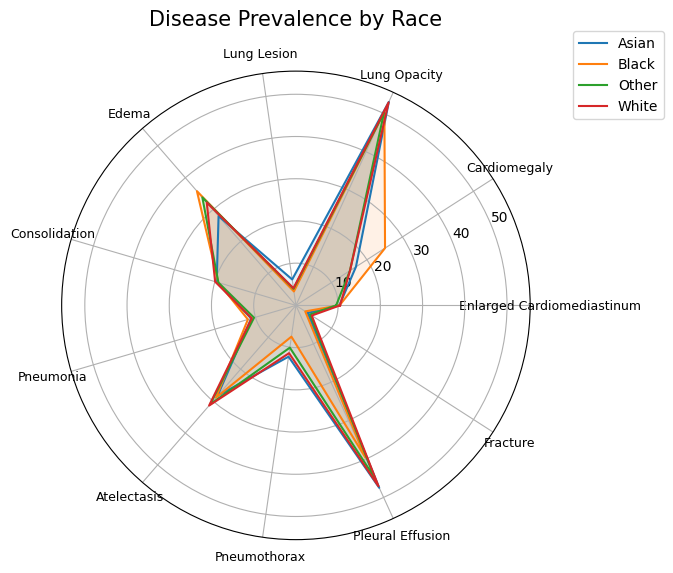

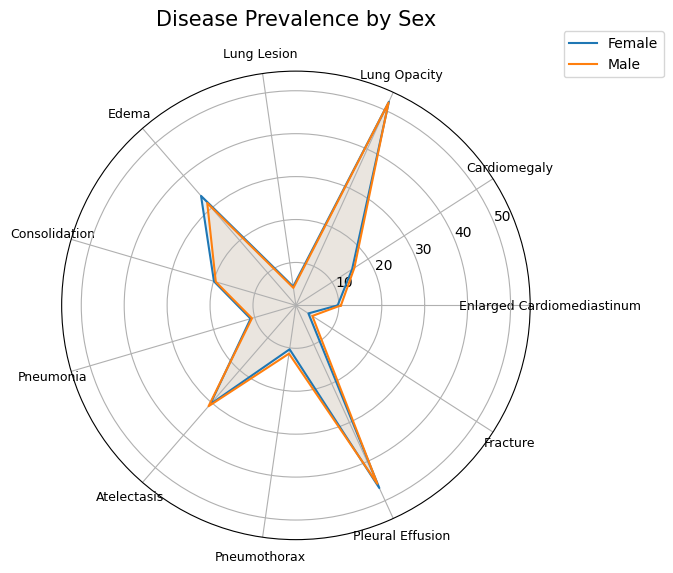

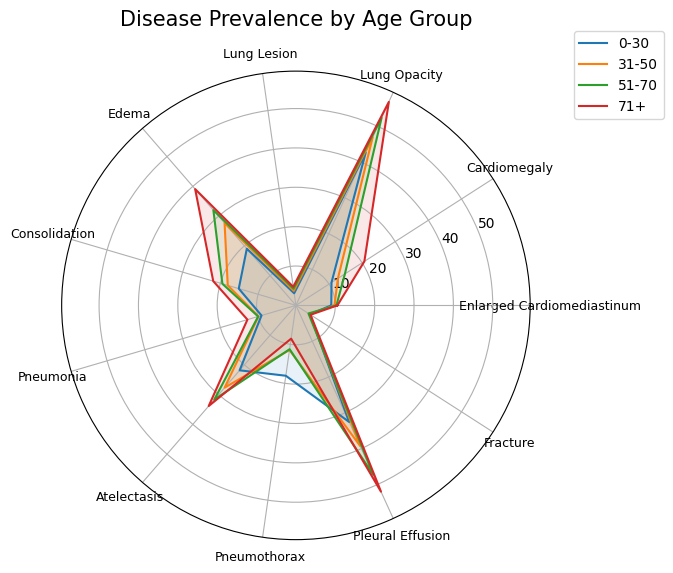

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess
df = pd.read_csv("/mnt/Internal/MedImage/merged_dataset.csv")
df = df[df['Frontal/Lateral'].str.contains('frontal', case=False, na=False)]
df.replace(-1, 1, inplace=True)
df.replace(np.nan, 0, inplace=True)
df = df[0:175000]

# Disease labels
disease_labels = [
    'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia',
    'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Fracture'
]

# Group columns
race_col = [col for col in df.columns if col.startswith('PRIMARY_RACE')][0]
df['Race_Group'] = df[race_col].fillna('Other').astype(str).apply(lambda x: (
    'Asian' if 'Asian' in x else
    'Black' if 'Black' in x else
    'White' if 'White' in x else
    'Other'
))

gender_col = [col for col in df.columns if col.startswith('Sex')][0]
df['Sex'] = df[gender_col].fillna('Unknown').astype(str).apply(lambda x: 'Male' if 'Male' in x else 'Female')

if 'Age' in df.columns:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 70, 150], labels=['0-30', '31-50', '51-70', '71+'])

# Prevalence calculator
def get_group_prevalence(df, group_col):
    result = {}
    for group in sorted(df[group_col].dropna().unique()):
        subset = df[df[group_col] == group]
        prevalence = [(subset[d] == 1).sum() / len(subset) * 100 for d in disease_labels]
        result[group] = prevalence
    return result

# Radar plot function
def plot_radar(data_dict, title):
    labels = disease_labels
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for group, values in data_dict.items():
        values += values[:1]  # Close the circle
        ax.plot(angles, values, label=group)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, size=15, y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

# Generate plots
race_prevalence = get_group_prevalence(df, 'Race_Group')
sex_prevalence = get_group_prevalence(df, 'Sex')
age_prevalence = get_group_prevalence(df, 'Age_Group')

plot_radar(race_prevalence, "Disease Prevalence by Race")
plot_radar(sex_prevalence, "Disease Prevalence by Sex")
plot_radar(age_prevalence, "Disease Prevalence by Age Group")
